# Chapter 12: Optimization and Gradients

**Book:** *Linear Algebra with Applications in Machine Learning: From Intuitive Understanding to Python Coding*

---

Optimization is the mathematical engine behind model training: find parameters that minimize a loss function. This notebook covers:

1. **Optimization Basics** -- objective functions, constrained vs. unconstrained, convexity
2. **Gradient Descent** -- update rule, learning rate, 1D and multi-dimensional cases
3. **Hessian and Second-Order Methods** -- Newton's method, curvature, convergence comparison
4. **Optimization in ML** -- linear regression (closed-form vs. GD), SGD, mini-batch, Adam
5. **Logistic Regression** -- cross-entropy loss, sigmoid, GD vs. Adam
6. **Regularization** -- Ridge regression, effect on weights

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
np.set_printoptions(precision=4, suppress=True)

print("All imports successful.")

All imports successful.


## 12.1 Optimization: Definition and Basics

Optimization seeks $\mathbf{x}^* = \arg\min_{\mathbf{x}} f(\mathbf{x})$. The function $f$ is the **objective** (or loss/cost function).

- **Unconstrained:** no restrictions on $\mathbf{x}$
- **Constrained:** $\mathbf{x}$ must satisfy conditions
- **Convex:** single global minimum (bowl-shaped); **Non-convex:** multiple local minima

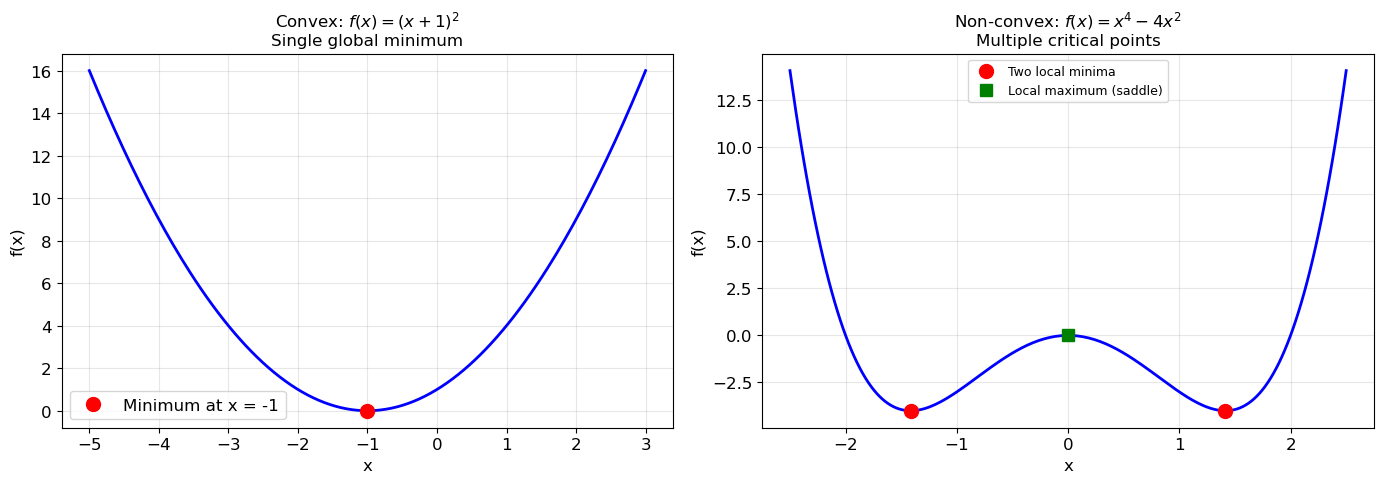

In [3]:
# Simple 1D example: f(x) = x^2 + 2x + 1 = (x+1)^2
x = np.linspace(-5, 3, 200)
f = x**2 + 2*x + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convex function
ax1.plot(x, f, 'b-', linewidth=2)
ax1.plot(-1, 0, 'ro', markersize=10, label='Minimum at x = -1')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Convex: $f(x) = (x+1)^2$\nSingle global minimum', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Non-convex function
x2 = np.linspace(-2.5, 2.5, 200)
f2 = x2**4 - 4*x2**2
ax2.plot(x2, f2, 'b-', linewidth=2)
ax2.plot([np.sqrt(2), -np.sqrt(2)], [-4, -4], 'ro', markersize=10, label='Two local minima')
ax2.plot(0, 0, 'gs', markersize=8, label='Local maximum (saddle)')
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.set_title('Non-convex: $f(x) = x^4 - 4x^2$\nMultiple critical points', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12.2 Gradient Descent

**Gradient descent** iteratively updates parameters by moving opposite to the gradient:

$$\mathbf{x}_{t+1} = \mathbf{x}_t - \eta \nabla f(\mathbf{x}_t)$$

- $\eta$ (learning rate) controls step size
- $\nabla f$ points uphill; we move downhill

### 1D Gradient Descent

In [4]:
def gradient_descent_1d(f, df, x0, lr, n_iter):
    """1D gradient descent with history tracking."""
    x = x0
    history = [(x, f(x))]
    for _ in range(n_iter):
        x = x - lr * df(x)
        history.append((x, f(x)))
    return x, history

# f(x) = (x+5)^2, minimum at x = -5
f = lambda x: (x + 5)**2
df = lambda x: 2*(x + 5)

x_opt, hist = gradient_descent_1d(f, df, x0=3, lr=0.2, n_iter=20)

print(f"Starting point: x0 = 3")
print(f"After 20 iterations: x = {x_opt:.6f}")
print(f"True minimum: x = -5")
print(f"\nFirst 6 steps:")
for i, (xi, fi) in enumerate(hist[:6]):
    print(f"  t={i}: x = {xi:8.4f}, f(x) = {fi:8.4f}")

Starting point: x0 = 3
After 20 iterations: x = -4.999708
True minimum: x = -5

First 6 steps:
  t=0: x =   3.0000, f(x) =  64.0000
  t=1: x =  -0.2000, f(x) =  23.0400
  t=2: x =  -2.1200, f(x) =   8.2944
  t=3: x =  -3.2720, f(x) =   2.9860
  t=4: x =  -3.9632, f(x) =   1.0750
  t=5: x =  -4.3779, f(x) =   0.3870


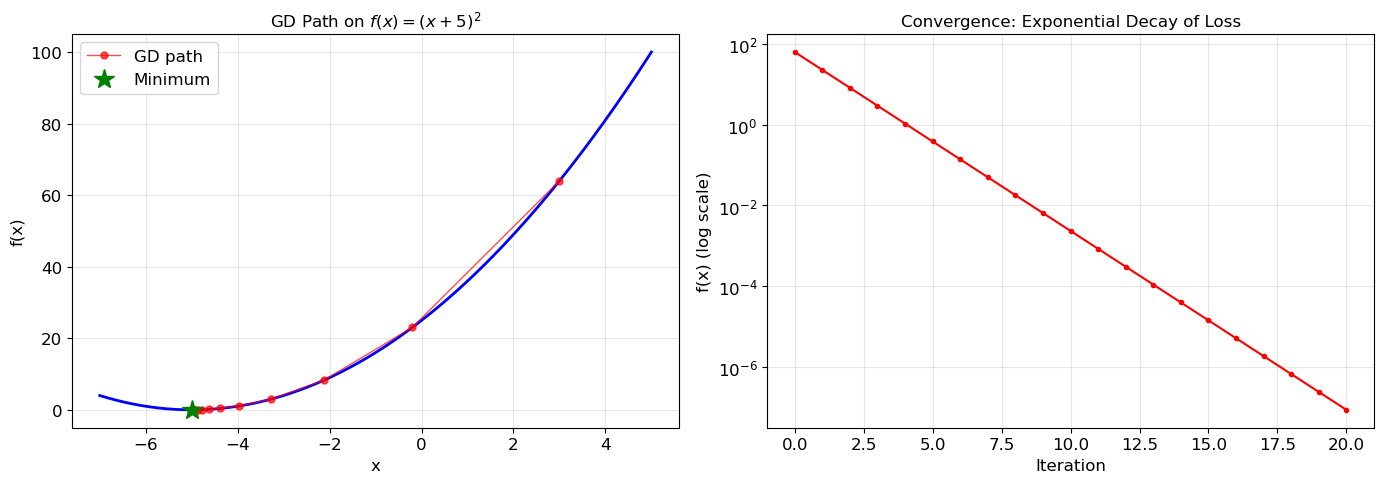

In [5]:
# Visualize GD convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Path on function
x_plot = np.linspace(-7, 5, 200)
ax1.plot(x_plot, [(xi+5)**2 for xi in x_plot], 'b-', linewidth=2)
xs = [h[0] for h in hist]
fs = [h[1] for h in hist]
ax1.plot(xs, fs, 'ro-', markersize=5, linewidth=1, alpha=0.7, label='GD path')
ax1.plot(-5, 0, 'g*', markersize=15, label='Minimum')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('GD Path on $f(x) = (x+5)^2$', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Convergence curve
ax2.semilogy(range(len(fs)), fs, 'r.-')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('f(x) (log scale)')
ax2.set_title('Convergence: Exponential Decay of Loss', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Effect of Learning Rate

Too small: slow convergence. Too large: overshooting or divergence.

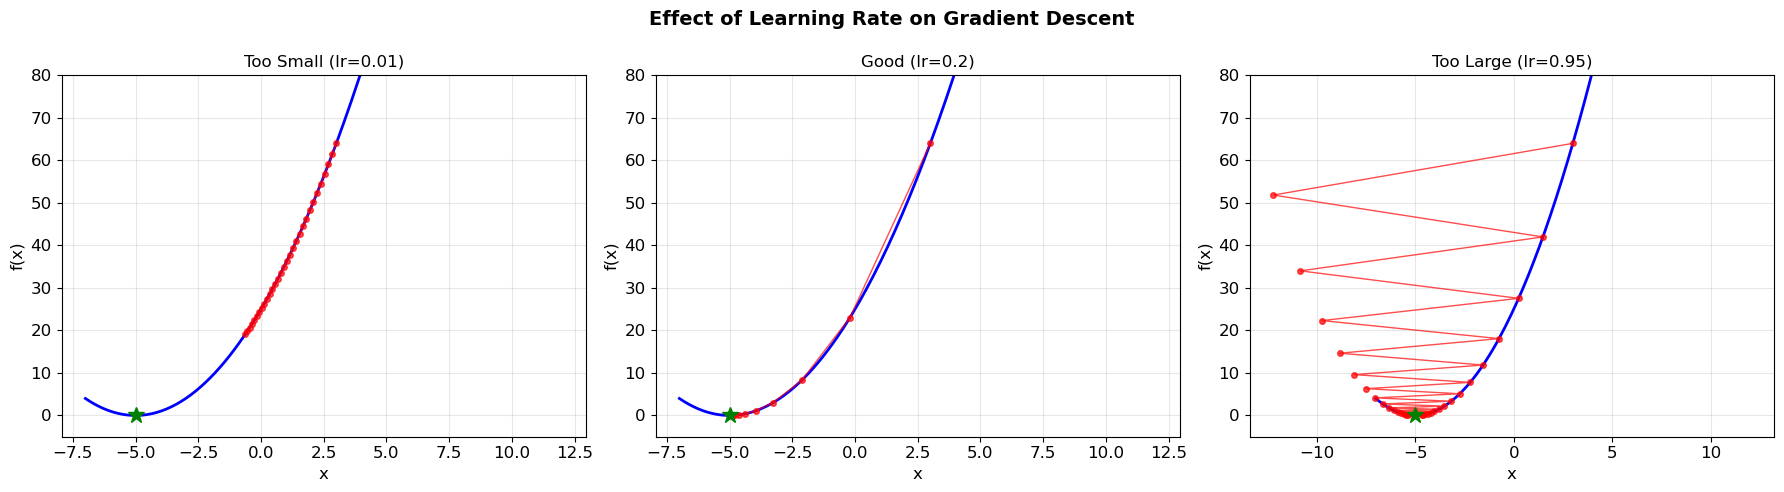

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lrs = [0.01, 0.2, 0.95]
titles = ['Too Small (lr=0.01)', 'Good (lr=0.2)', 'Too Large (lr=0.95)']

x_plot = np.linspace(-7, 12, 200)

for ax, lr, title in zip(axes, lrs, titles):
    _, hist_lr = gradient_descent_1d(f, df, x0=3, lr=lr, n_iter=30)
    xs = [h[0] for h in hist_lr]
    fs = [h[1] for h in hist_lr]
    
    ax.plot(x_plot, [(xi+5)**2 for xi in x_plot], 'b-', linewidth=2)
    ax.plot(xs, fs, 'ro-', markersize=4, linewidth=1, alpha=0.7)
    ax.plot(-5, 0, 'g*', markersize=12)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_ylim(-5, 80)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Learning Rate on Gradient Descent', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2D Gradient Descent

In [7]:
def gradient_descent_2d(grad_f, x0, y0, lr, n_iter):
    """2D gradient descent."""
    x, y = x0, y0
    history = [(x, y)]
    for _ in range(n_iter):
        gx, gy = grad_f(x, y)
        x = x - lr * gx
        y = y - lr * gy
        history.append((x, y))
    return x, y, history

# f(x,y) = x^2 + y^2, gradient = (2x, 2y)
grad_f = lambda x, y: (2*x, 2*y)
x_opt, y_opt, hist2d = gradient_descent_2d(grad_f, 2, 3, lr=0.1, n_iter=50)

print(f"Optimal point: ({x_opt:.6f}, {y_opt:.6f})")
print(f"True minimum: (0, 0)")

Optimal point: (0.000029, 0.000043)
True minimum: (0, 0)


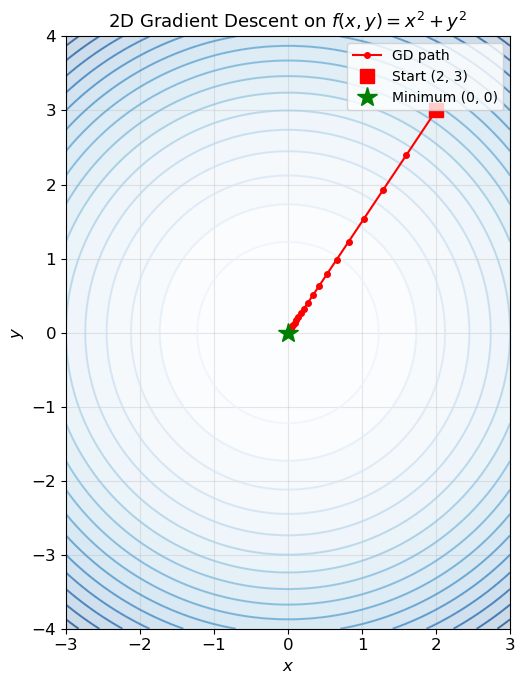

In [8]:
# Visualize with contour plot
fig, ax = plt.subplots(figsize=(8, 7))

xg = np.linspace(-3, 3, 100)
yg = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(xg, yg)
Z = X**2 + Y**2

ax.contour(X, Y, Z, levels=20, cmap='Blues', alpha=0.6)
ax.contourf(X, Y, Z, levels=20, cmap='Blues', alpha=0.2)

path = np.array(hist2d)
ax.plot(path[:, 0], path[:, 1], 'ro-', markersize=4, linewidth=1.5, label='GD path')
ax.plot(path[0, 0], path[0, 1], 'rs', markersize=10, label=f'Start ({path[0,0]:.0f}, {path[0,1]:.0f})')
ax.plot(0, 0, 'g*', markersize=15, label='Minimum (0, 0)')

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_title('2D Gradient Descent on $f(x,y) = x^2 + y^2$', fontsize=13)
ax.legend(fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### GD on an Elongated Quadratic (Ill-Conditioned)

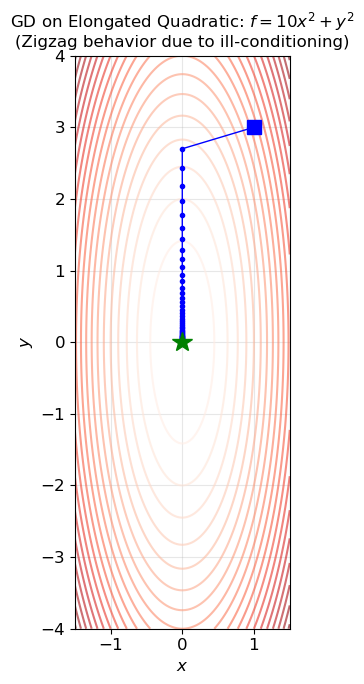

In [9]:
# f(x,y) = 10*x^2 + y^2: very different curvatures along x and y
grad_elong = lambda x, y: (20*x, 2*y)
_, _, hist_elong = gradient_descent_2d(grad_elong, 1, 3, lr=0.05, n_iter=60)

fig, ax = plt.subplots(figsize=(8, 7))
X2, Y2 = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-4, 4, 100))
Z2 = 10*X2**2 + Y2**2

ax.contour(X2, Y2, Z2, levels=20, cmap='Reds', alpha=0.6)
path_e = np.array(hist_elong)
ax.plot(path_e[:, 0], path_e[:, 1], 'bo-', markersize=3, linewidth=1)
ax.plot(path_e[0, 0], path_e[0, 1], 'bs', markersize=10)
ax.plot(0, 0, 'g*', markersize=15)

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_title('GD on Elongated Quadratic: $f = 10x^2 + y^2$\n(Zigzag behavior due to ill-conditioning)', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12.3 Hessian and Second-Order Methods

The **Hessian** $H$ is the matrix of second derivatives: $H_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}$.

**Newton's method** uses curvature to take smarter steps:

$$\mathbf{x}_{t+1} = \mathbf{x}_t - H^{-1} \nabla f(\mathbf{x}_t)$$

For quadratic functions, Newton converges in **one step**. For general smooth functions, it achieves **quadratic convergence** near the optimum.

### 1D Newton's Method

In [10]:
def newton_1d(f, df, ddf, x0, n_iter=20, tol=1e-10):
    """1D Newton's method with history."""
    x = x0
    history = [(x, f(x))]
    for _ in range(n_iter):
        g = df(x)
        h = ddf(x)
        if abs(g) < tol:
            break
        if abs(h) < 1e-12:
            break
        x = x - g / h
        history.append((x, f(x)))
    return x, history

# f(x) = x^4 - 4x^2, minima at x = +/- sqrt(2)
f_nc = lambda x: x**4 - 4*x**2
df_nc = lambda x: 4*x**3 - 8*x
ddf_nc = lambda x: 12*x**2 - 8

x_newton, hist_newton = newton_1d(f_nc, df_nc, ddf_nc, x0=2.0)
x_gd, hist_gd = gradient_descent_1d(f_nc, df_nc, x0=2.0, lr=0.05, n_iter=50)

print(f"Newton's method: x = {x_newton:.6f} in {len(hist_newton)-1} steps")
print(f"Gradient descent: x = {x_gd:.6f} in {len(hist_gd)-1} steps")
print(f"True minimum: x = {np.sqrt(2):.6f}")

Newton's method: x = 1.414214 in 5 steps
Gradient descent: x = 1.414214 in 50 steps
True minimum: x = 1.414214


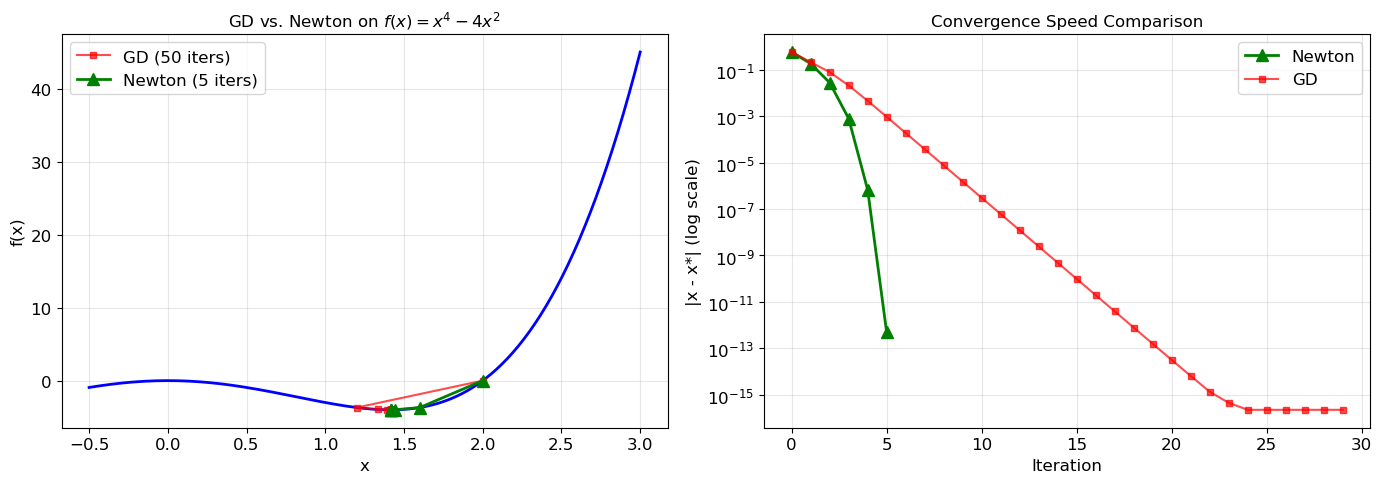

In [11]:
# Compare convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Paths on function
x_plot = np.linspace(-0.5, 3, 200)
ax1.plot(x_plot, [xi**4 - 4*xi**2 for xi in x_plot], 'b-', linewidth=2)
xs_n = [h[0] for h in hist_newton]
fs_n = [h[1] for h in hist_newton]
xs_g = [h[0] for h in hist_gd[:20]]
fs_g = [h[1] for h in hist_gd[:20]]
ax1.plot(xs_g, fs_g, 'rs-', markersize=5, label=f'GD ({len(hist_gd)-1} iters)', alpha=0.7)
ax1.plot(xs_n, fs_n, 'g^-', markersize=8, label=f'Newton ({len(hist_newton)-1} iters)', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('GD vs. Newton on $f(x) = x^4 - 4x^2$', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Error vs iteration
x_star = np.sqrt(2)
err_n = [abs(h[0] - x_star) for h in hist_newton]
err_g = [abs(h[0] - x_star) for h in hist_gd[:30]]
ax2.semilogy(range(len(err_n)), err_n, 'g^-', label='Newton', markersize=8, linewidth=2)
ax2.semilogy(range(len(err_g)), err_g, 'rs-', label='GD', markersize=4, alpha=0.7)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('|x - x*| (log scale)')
ax2.set_title('Convergence Speed Comparison', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2D Newton's Method: Quadratic Function (One-Step Convergence)

In [12]:
# f(x,y) = x^2 + xy + y^2 - 6x - 9y
# grad = [2x + y - 6, x + 2y - 9]
# H = [[2, 1], [1, 2]]  (constant!)

H = np.array([[2, 1], [1, 2]], dtype=float)
H_inv = np.linalg.inv(H)

x0 = np.array([0.0, 0.0])
grad0 = np.array([2*x0[0] + x0[1] - 6, x0[0] + 2*x0[1] - 9])

x1 = x0 - H_inv @ grad0

print(f"Hessian H =\n{H}")
print(f"H^(-1) =\n{H_inv.round(4)}")
print(f"\nStarting point: {x0}")
print(f"Gradient at start: {grad0}")
print(f"Newton step: {x1}")
print(f"\nFor quadratic functions, Newton converges in exactly ONE step!")

# Verify: gradient at x1 should be zero
grad1 = np.array([2*x1[0] + x1[1] - 6, x1[0] + 2*x1[1] - 9])
print(f"Gradient at x1: {grad1}  (zero => minimum found)")

Hessian H =
[[2. 1.]
 [1. 2.]]
H^(-1) =
[[ 0.6667 -0.3333]
 [-0.3333  0.6667]]

Starting point: [0. 0.]
Gradient at start: [-6. -9.]
Newton step: [1. 4.]

For quadratic functions, Newton converges in exactly ONE step!
Gradient at x1: [0. 0.]  (zero => minimum found)


### Hessian Eigenvalues and Critical Point Classification

In [13]:
# Different Hessians at critical points
hessians = [
    ("Local minimum (positive definite)", np.array([[2, 0], [0, 3]])),
    ("Local maximum (negative definite)", np.array([[-2, 0], [0, -3]])),
    ("Saddle point (indefinite)", np.array([[2, 0], [0, -3]])),
    ("Degenerate (positive semidefinite)", np.array([[2, 0], [0, 0]])),
]

print(f"{'Type':45s} {'Eigenvalues':>15s} {'det(H)':>8s}")
print("-" * 72)
for name, H in hessians:
    eigs = np.linalg.eigvalsh(H)
    det = np.linalg.det(H)
    print(f"{name:45s} {str(eigs.round(2)):>15s} {det:8.1f}")

Type                                              Eigenvalues   det(H)
------------------------------------------------------------------------
Local minimum (positive definite)                     [2. 3.]      6.0
Local maximum (negative definite)                   [-3. -2.]      6.0
Saddle point (indefinite)                           [-3.  2.]     -6.0
Degenerate (positive semidefinite)                    [0. 2.]      0.0


## 12.4 Optimization in Machine Learning

### Linear Regression: Closed-Form vs. Gradient Descent

The MSE loss is $L(\mathbf{w}) = \frac{1}{n}\|X\mathbf{w} - \mathbf{y}\|^2$. The closed-form solution is $\mathbf{w} = (X^TX)^{-1}X^T\mathbf{y}$.

In [14]:
X = np.array([[1, 2], [3, 4], [5, 6]], dtype=float)
y = np.array([3, 7, 11], dtype=float)

# Closed-form solution
w_closed = np.linalg.pinv(X.T @ X) @ X.T @ y
print(f"Closed-form weights: {w_closed}")
print(f"Predictions: {X @ w_closed}")
print(f"True y: {y}")

# Gradient descent for linear regression
def gd_linear_regression(X, y, lr, n_iter):
    n = len(y)
    w = np.zeros(X.shape[1])
    losses = []
    for _ in range(n_iter):
        pred = X @ w
        error = pred - y
        loss = np.mean(error**2)
        losses.append(loss)
        grad = (2/n) * X.T @ error
        w = w - lr * grad
    return w, losses

w_gd, losses_gd = gd_linear_regression(X, y, lr=0.01, n_iter=500)
print(f"\nGD weights (500 iters): {w_gd.round(4)}")
print(f"Match closed-form: {np.allclose(w_gd, w_closed, atol=0.01)}")

Closed-form weights: [1. 1.]
Predictions: [ 3.  7. 11.]
True y: [ 3.  7. 11.]

GD weights (500 iters): [0.9463 1.0424]
Match closed-form: False


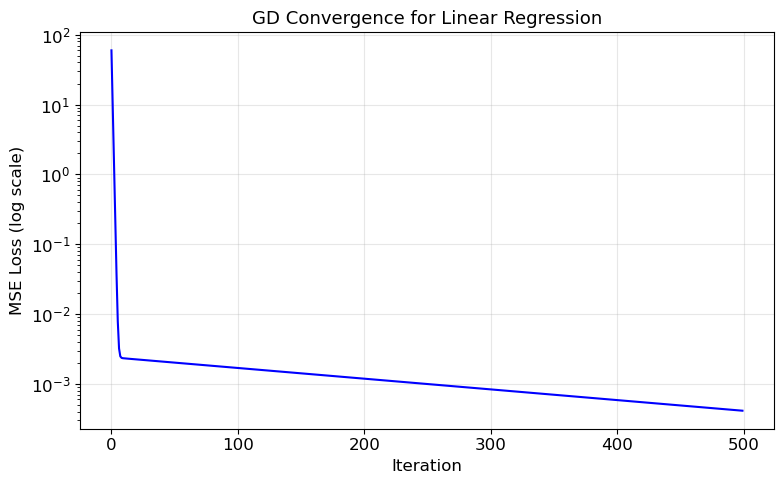

In [15]:
# Convergence of GD for linear regression
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(losses_gd, 'b-', linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('MSE Loss (log scale)')
ax.set_title('GD Convergence for Linear Regression', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Stochastic Gradient Descent (SGD)

SGD uses a **single random sample** per step instead of the full dataset, trading accuracy for speed.

In [16]:
def sgd_linear_regression(X, y, lr, n_iter):
    n = len(y)
    w = np.zeros(X.shape[1])
    losses = []
    for _ in range(n_iter):
        idx = np.random.randint(0, n)
        xi, yi = X[idx], y[idx]
        pred = np.dot(xi, w)
        error = pred - yi
        grad = error * xi
        w = w - lr * grad
        loss = np.mean((X @ w - y)**2)
        losses.append(loss)
    return w, losses

np.random.seed(42)
w_sgd, losses_sgd = sgd_linear_regression(X, y, lr=0.01, n_iter=500)

print(f"SGD weights: {w_sgd.round(4)}")
print(f"Closed-form: {w_closed.round(4)}")

SGD weights: [0.9318 1.0547]
Closed-form: [1. 1.]


### Mini-Batch Gradient Descent

In [17]:
def minibatch_gd(X, y, lr, n_iter, batch_size):
    n = len(y)
    w = np.zeros(X.shape[1])
    losses = []
    for _ in range(n_iter):
        indices = np.random.choice(n, min(batch_size, n), replace=False)
        Xb, yb = X[indices], y[indices]
        pred = Xb @ w
        error = pred - yb
        grad = (2/len(yb)) * Xb.T @ error
        w = w - lr * grad
        loss = np.mean((X @ w - y)**2)
        losses.append(loss)
    return w, losses

np.random.seed(42)
w_mb, losses_mb = minibatch_gd(X, y, lr=0.01, n_iter=500, batch_size=2)
print(f"Mini-batch weights: {w_mb.round(4)}")

Mini-batch weights: [0.9397 1.0467]


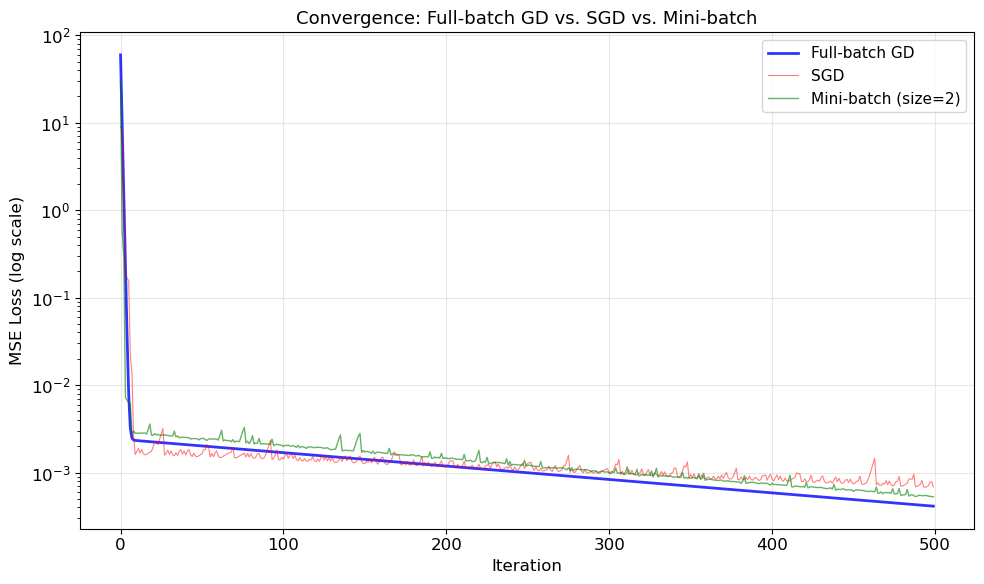

In [18]:
# Compare convergence: GD vs SGD vs Mini-batch
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(losses_gd, 'b-', linewidth=2, label='Full-batch GD', alpha=0.8)
ax.semilogy(losses_sgd, 'r-', linewidth=0.8, label='SGD', alpha=0.5)
ax.semilogy(losses_mb, 'g-', linewidth=1, label='Mini-batch (size=2)', alpha=0.6)
ax.set_xlabel('Iteration')
ax.set_ylabel('MSE Loss (log scale)')
ax.set_title('Convergence: Full-batch GD vs. SGD vs. Mini-batch', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Logistic Regression: GD vs. Adam

Binary cross-entropy loss with sigmoid activation. Adam adapts the learning rate per-parameter using moment estimates.

In [19]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def log_loss(X, y, w):
    p = sigmoid(X @ w)
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def gd_logistic(X, y, lr, n_iter):
    w = np.zeros(X.shape[1])
    losses = []
    for _ in range(n_iter):
        p = sigmoid(X @ w)
        grad = X.T @ (p - y) / len(y)
        w = w - lr * grad
        losses.append(log_loss(X, y, w))
    return w, losses

def adam_logistic(X, y, lr, n_iter, beta1=0.9, beta2=0.999, eps=1e-8):
    w = np.zeros(X.shape[1])
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    losses = []
    for t in range(1, n_iter + 1):
        p = sigmoid(X @ w)
        grad = X.T @ (p - y) / len(y)
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        losses.append(log_loss(X, y, w))
    return w, losses

X_log = np.array([[1, 2], [2, 3], [3, 4], [4, 5]], dtype=float)
y_log = np.array([0, 0, 1, 1], dtype=float)

w_gd_log, losses_gd_log = gd_logistic(X_log, y_log, lr=0.1, n_iter=1000)
w_adam_log, losses_adam_log = adam_logistic(X_log, y_log, lr=0.01, n_iter=1000)

print(f"GD weights:   {w_gd_log.round(4)}")
print(f"Adam weights: {w_adam_log.round(4)}")

GD weights:   [ 4.917  -3.4171]
Adam weights: [ 5.9401 -4.1586]


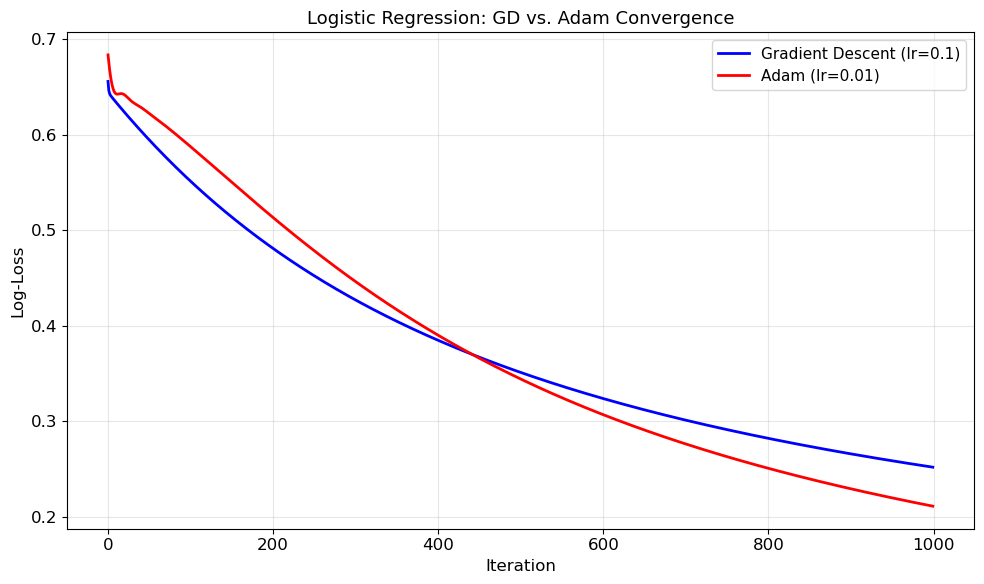

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(losses_gd_log, 'b-', linewidth=2, label='Gradient Descent (lr=0.1)')
ax.plot(losses_adam_log, 'r-', linewidth=2, label='Adam (lr=0.01)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Log-Loss')
ax.set_title('Logistic Regression: GD vs. Adam Convergence', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Ridge Regression (L2 Regularization)

Adds $\lambda \|\mathbf{w}\|^2$ to the loss. The closed-form becomes $\mathbf{w} = (X^TX + \lambda I)^{-1} X^T \mathbf{y}$, which is always invertible.

In [21]:
X_ridge = np.array([[1, 2], [3, 4], [5, 6]], dtype=float)
y_ridge = np.array([3, 7, 11], dtype=float)

lambdas = [0, 0.01, 0.1, 1.0, 10.0]
print(f"{'Lambda':>8s}  {'w1':>8s}  {'w2':>8s}  {'||w||':>8s}")
print("-" * 38)
for lam in lambdas:
    n_feat = X_ridge.shape[1]
    w = np.linalg.solve(X_ridge.T @ X_ridge + lam * np.eye(n_feat), X_ridge.T @ y_ridge)
    print(f"{lam:8.2f}  {w[0]:8.4f}  {w[1]:8.4f}  {np.linalg.norm(w):8.4f}")

print("\nAs lambda increases, weights shrink toward zero (regularization effect).")

  Lambda        w1        w2     ||w||
--------------------------------------
    0.00    1.0000    1.0000    1.4142
    0.01    0.9952    1.0036    1.4134
    0.10    0.9635    1.0269    1.4081
    1.00    0.8879    1.0690    1.3896
   10.00    0.7872    0.9903    1.2651

As lambda increases, weights shrink toward zero (regularization effect).


## 12.5 Exercises

Selected exercises from the chapter.

**Exercise 4:** Analyze the effect of learning rates (0.001, 0.01, 0.1) on GD convergence for $f(x) = x^4 - 4x^2$.

In [22]:
# Exercise 4: Your code here


**Exercise 7:** Generate a 3D plot of the GD optimization path for $f(x,y) = x^2 + y^2$, starting from (2, 3).

In [23]:
# Exercise 7: Your code here


**Exercise 11:** Compute the closed-form LR solution and compare with SGD. Calculate MSE for both.

In [24]:
# Exercise 11: Your code here


---

## Exercise Solutions

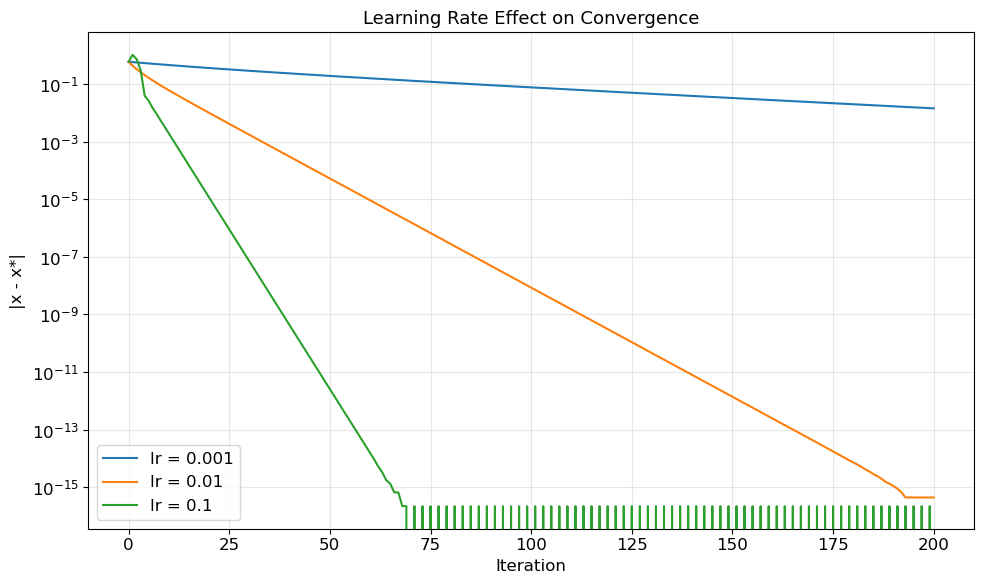

In [25]:
# --- Solution: Exercise 4 ---
fig, ax = plt.subplots(figsize=(10, 6))
for lr in [0.001, 0.01, 0.1]:
    _, hist_ex = gradient_descent_1d(f_nc, df_nc, x0=2.0, lr=lr, n_iter=200)
    err = [abs(h[0] - np.sqrt(2)) for h in hist_ex]
    ax.semilogy(err, label=f'lr = {lr}')
ax.set_xlabel('Iteration')
ax.set_ylabel('|x - x*|')
ax.set_title('Learning Rate Effect on Convergence', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

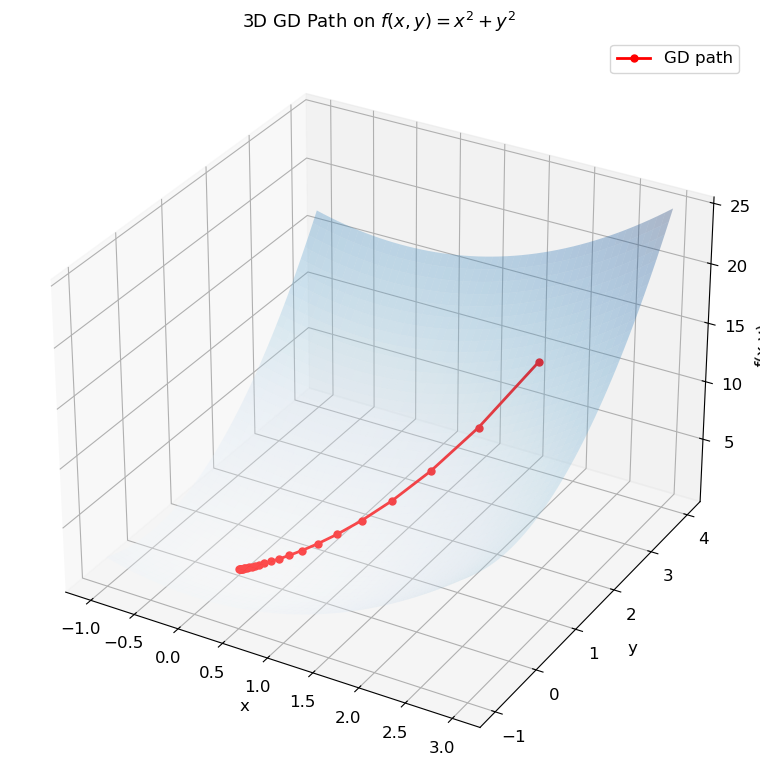

In [26]:
# --- Solution: Exercise 7 ---
_, _, hist3d = gradient_descent_2d(lambda x, y: (2*x, 2*y), 2, 3, lr=0.1, n_iter=25)
path3d = np.array(hist3d)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
xg = np.linspace(-1, 3, 50)
yg = np.linspace(-1, 4, 50)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg**2 + Yg**2
ax.plot_surface(Xg, Yg, Zg, alpha=0.3, cmap='Blues')
ax.plot(path3d[:, 0], path3d[:, 1], path3d[:, 0]**2 + path3d[:, 1]**2,
        'ro-', markersize=5, linewidth=2, label='GD path')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('3D GD Path on $f(x,y) = x^2 + y^2$', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# --- Solution: Exercise 11 ---
X = np.array([[1, 2], [3, 4], [5, 6]], dtype=float)
y = np.array([3, 7, 11], dtype=float)

w_cf = np.linalg.pinv(X.T @ X) @ X.T @ y
np.random.seed(0)
w_sgd_ex, _ = sgd_linear_regression(X, y, lr=0.01, n_iter=2000)

mse_cf = np.mean((X @ w_cf - y)**2)
mse_sgd = np.mean((X @ w_sgd_ex - y)**2)

print(f"Closed-form: w = {w_cf.round(4)}, MSE = {mse_cf:.6f}")
print(f"SGD:         w = {w_sgd_ex.round(4)}, MSE = {mse_sgd:.6f}")

Closed-form: w = [1. 1.], MSE = 0.000000
SGD:         w = [0.9738 1.0214], MSE = 0.000110
